In [1]:
import torch

if torch.cuda.is_available():
    idx = 0
    prop = torch.cuda.get_device_properties(idx)
    print(f"Name:            {prop.name}")
    print(f"Total memory:    {prop.total_memory/1e9:.1f} GB")
    print(f"Compute device:  {prop.major}.{prop.minor}")
else:
    print("No CUDA device available")


Name:            NVIDIA GeForce RTX 2080 Ti
Total memory:    11.4 GB
Compute device:  7.5


In [3]:
import json
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F
from loguru import logger
from omegaconf import OmegaConf
from scipy.stats import spearmanr
from torch_geometric.nn import knn_graph
from torch_cluster.knn import knn
from tqdm import tqdm
from collections import defaultdict
import pandas as pd

sys.path.append("/nfs/homedirs/dhp/unsupervised-data-pruning/src")

from utils.helpers import parse_config
from utils.dataset import prepare_data
from utils.models import load_model_by_name


In [4]:
import pandas as pd
from torch_geometric.nn import knn_graph

def compute_knn_statistics(embeddings, labels, full_scores_dict, extrapolated_scores_dict, rank_full, rank_extrapolated, k=50, device=torch.device("cuda")):
    edge_index = knn_graph(embeddings, k=k, loop=False)
    src, dst = edge_index

    # Compute distances for each edge
    distances = (embeddings[src] - embeddings[dst]).pow(2).sum(dim=1).sqrt()

    # Convert to dictionary: each node -> list of (neighbor, distance)
    from collections import defaultdict

    knn_dict = defaultdict(list)
    for s, d, dist in zip(src.tolist(), dst.tolist(), distances.tolist()):
        knn_dict[s].append((d, dist))

    rows = []
    for idx_str in list(full_scores_dict.keys()):
        idx = int(idx_str)
        label = labels[idx].item()
        neighbors = knn_dict[idx]

        if not neighbors:
            stats = [-1, -1, -1, -1, 0]
        else:
            dists = torch.tensor([d for _, d in neighbors], device=device)
            neighbor_indices = torch.tensor([i for i, _ in neighbors], device=device)
            neighbor_labels = labels[neighbor_indices].to(device)
            same_label_mask = (neighbor_labels == label)
            
            # dists = torch.tensor([d for _, d in neighbors])
            # neighbor_indices = [i for i, _ in neighbors]
            # neighbor_labels = labels[neighbor_indices]
            # same_label_mask = (neighbor_labels == label)

            min_dist = dists.min().item()
            mean_dist = dists.mean().item()

            if same_label_mask.any():
                same_label_dists = dists[same_label_mask]
                min_same = same_label_dists.min().item()
                mean_same = same_label_dists.mean().item()
                count_same = same_label_mask.sum().item()
            else:
                continue
                min_same = 1000
                mean_same = 1000
                count_same = 0

            stats = [min_dist, min_same, mean_dist, mean_same, count_same]

        rows.append({
            "true_index": idx,
            "true_label": label,
            "true_score": full_scores_dict[idx_str],
            "extrapolated_score": extrapolated_scores_dict[idx_str],
            "rank_full": rank_full[idx_str],
            "rank_extrapolated": rank_extrapolated[idx_str],
            "min_dist": stats[0],
            "min_dist_same_label": stats[1],
            "mean_dist": stats[2],
            "mean_dist_same_label": stats[3],
            "num_same_label_neighbors": stats[4],
        })

    df = pd.DataFrame(rows)
    return df


In [5]:
cfg = OmegaConf.load("/nfs/homedirs/dhp/unsupervised-data-pruning/src/extrapolate/configs/gnn_config.yaml")
cfg = cfg.CIFAR10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

trainset, train_loader, _, num_samples = prepare_data(cfg.dataset, 1024)

with open("/nfs/homedirs/dhp/unsupervised-data-pruning/scores/prune/CIFAR10_dynamic_uncertainty_0.json") as f:
    full_scores_dict = json.load(f)

with open("/nfs/homedirs/dhp/unsupervised-data-pruning/scores/extrapolation/extrapolated/gnn_DU_CIFAR10_resnet50-self-trained_k_10_seed_20000_euclidean.json") as f:
    extrapolated_scores_dict = json.load(f)

labels_tensor = torch.zeros(num_samples, dtype=torch.int64, device=device)

embedding_model = load_model_by_name("resnet50-self-trained", 10, 32,
    "/nfs/homedirs/dhp/unsupervised-data-pruning/models/CIFAR10/subset_data/dynamic_uncertainty.pth", device,
)
embedding_model.eval()

sample_input, _, _ = trainset[0]  # first sample, ignore label & idx
sample_input = sample_input.unsqueeze(0).to(device)
with torch.no_grad():
    sample_output = embedding_model(sample_input)
embedding_dim = sample_output.shape[1]

embeddings = torch.zeros(num_samples, embedding_dim, device=device)

for images, labels, sample_idxs in tqdm(
    train_loader, mininterval=20, maxinterval=40
):
    images = images.to(device)
    sample_idxs = sample_idxs.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        batch_embeddings = embedding_model(images)

    embeddings[sample_idxs] = batch_embeddings
    labels_tensor[sample_idxs] = labels

full_scores_dict_sorted = dict(sorted(full_scores_dict.items(), key=lambda item: item[1]))
extrapolated_scores_dict_sorted = dict(
    sorted(extrapolated_scores_dict.items(), key=lambda item: item[1])
)
full_scores_ranks = {
    k: i for i, k in enumerate(full_scores_dict_sorted.keys())
}
extrapolated_scores_ranks = {
    k: i for i, k in enumerate(extrapolated_scores_dict_sorted.keys())
}

Files already downloaded and verified
Files already downloaded and verified


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:14<00:00,  3.32it/s]


In [7]:
top_100_stats = compute_knn_statistics(
    embeddings,
    labels_tensor,
    full_scores_dict,
    extrapolated_scores_dict,
    full_scores_ranks,
    extrapolated_scores_ranks,
    k=20,
    device=device,
)

In [8]:
top_100_stats.head()

,true_index,true_label,true_score,extrapolated_score,rank_full,rank_extrapolated,min_dist,min_dist_same_label,mean_dist,mean_dist_same_label,num_same_label_neighbors
0,0,6,0.192147,0.244268,38490,49595,8.688478,8.688478,10.765008,10.748501,85
1,1,9,0.040836,0.103226,5246,5988,12.554402,12.554402,15.081572,15.081572,14
2,2,9,0.169299,0.223631,32788,48981,13.043564,13.043564,14.774802,14.990183,14
3,3,4,0.167935,0.091523,32410,4132,8.907251,8.907251,12.107978,12.141734,48
4,4,1,0.031542,0.086767,3186,3512,13.439631,13.439631,18.036167,18.036167,33


In [9]:
# add columns true_diff, abs_diff, and rank_diff for the indices as well
top_100_stats["true_diff"] = (
    top_100_stats["true_score"] - top_100_stats["extrapolated_score"]
)
top_100_stats["abs_diff"] = top_100_stats["true_diff"].abs()
top_100_stats["true_rank_diff"] = top_100_stats["rank_full"] - top_100_stats["rank_extrapolated"]
top_100_stats["abs_rank_diff"] = top_100_stats["true_rank_diff"].abs()

In [10]:
correlation = top_100_stats.corr(method="spearman")
correlation = correlation.drop(columns=["true_index"])
correlation = correlation.drop(index=["true_index"])


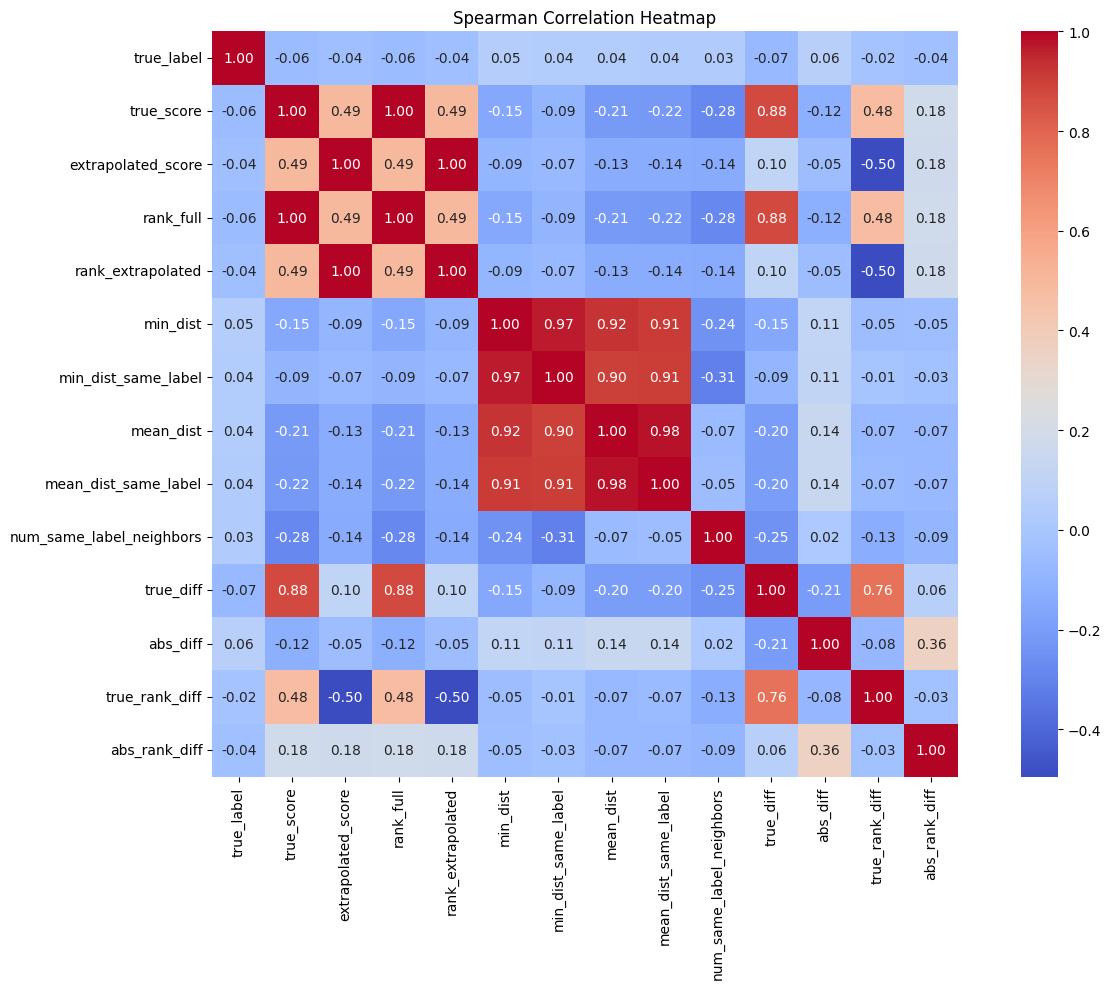

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()
